## Electric Guitar ##  
The solid body of an electric guitar does not resonate, instead, the string signal is read by a pickup and converted to voltage which is outputted by speakers. This results in less energy decay and a longer sustained note. Furthermore, the sound can be modified during the signal transfer to the speakers.

**The String**: Same principle as acoustic but electric guitar string are made of ferromagnetic materials. Thus, they are weightier. In concerns of sound, we consider two string types: solid string and wound string. The key difference is stiffness, under high stiffness, the string behaves like a bar so higher partials go progressively sharp $f_n \approx n \cdot f_0 \sqrt{(1+B_n)^2}$ while a wound string avoids this stiffness.

Mass also changes the drive of the string, the impedance is $Z = \sqrt{T \mu} $ so heavier string has higher impedence which leads to a sound that is louder, with stronger fundamentals and longer sustain. 

**The Body**

**The Pickup**

**Post-Pickup**

In [ ]:
%matplotlib inline
import numpy as np, wave, struct
import matplotlib.pyplot as plt
import scipy
from IPython.display import display, Audio

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root
from realsound import pluck_string, make_scale, play_sequence, measure_frequency

In [ ]:
def pluck_string_electric(f, beta=0.1, duration=3.0, fs=44100, rho=0.998, b=0.5):
    D = fs / f - b                        
    N = int(D)
    frac = D - N
    p = max(int(beta * N), 1)
    pluck = np.concatenate((np.linspace(0, 1, p), np.linspace(1, 0, N - p)))
    L = N + 2
    buf = np.zeros(L); buf[:N] = pluck
    out = np.zeros(int(fs * duration))
    w = 0; last = 0.0
    for i in range(len(out)):
        r0 = (w - N) % L                  
        r1 = (w - N - 1) % L              
        y = (1 - frac) * buf[r0] + frac * buf[r1]
        buf[w] = ((1 - b) * y + b * last) * rho    # loop filter, then round-trip loss
        last = y; out[i] = y; w = (w + 1) % L
    return out

In [ ]:
def dc_block(x, fs=44100, fc=7.0):
    a = np.exp(-2 * np.pi * fc / fs)      # pole radius <-> cutoff in Hz
    return scipy.signal.lfilter([1, -1], [1, -a], x)

In [ ]:
def plot_waveform_spectrum(output, name="output", fs=44100, fmax=8000):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    t_ms = np.arange(len(output)) / fs * 1000
    ax[0].plot(t_ms, output)
    ax[0].set_title(f"waveform - {name}"); ax[0].set_xlabel('ms'); ax[0].set_ylabel('amp')
    X = np.abs(np.fft.rfft(output * np.hanning(len(output))))
    f = np.fft.rfftfreq(len(output), 1 / fs)
    ref = X[f > 20].max()
    ax[1].plot(f, 20 * np.log10(X / ref + 1e-9))
    ax[1].set_xlim(0, fmax); ax[1].set_ylim(-80, 5)
    ax[1].set_title(f"spectrum - {name}"); ax[1].set_xlabel('Hz'); ax[1].set_ylabel('dB')
    plt.tight_layout(); plt.show()

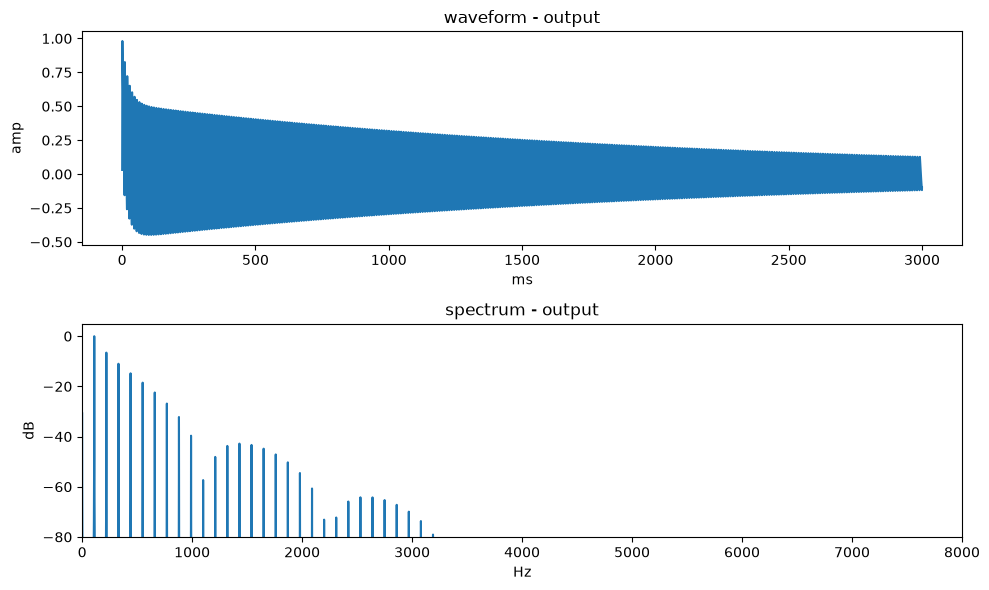

In [20]:
out = pluck_string_electric(f=110, beta=0.1, rho=0.996, b=0.1, duration=3.0)
out = dc_block(out)
plot_waveform_spectrum(out)
display(Audio(out,rate=44100))

In [21]:
def frac_comb(x, D):
    """y[n] = x[n] - x[n-D], with fractional D by linear interpolation.
 
    WHY A MINUS SIGN. d'Alembert: string motion at any point is the sum of a
    right-going and a left-going wave. The left-going wave at the pickup IS the
    right-going wave after it has run to the bridge and reflected -- and a pinned
    termination reflects with INVERSION. So the pickup sees the wave minus a
    delayed copy of itself. The minus is the bridge; the delay is the round trip
    pickup -> bridge -> pickup.
    """
    i = int(np.floor(D)); f = D - i
    d = np.zeros_like(x)
    d[i:]   = (1 - f) * x[:len(x) - i]
    if i + 1 < len(x):
        d[i+1:] += f * x[:len(x) - i - 1]
    return x - d

In [22]:
def rlc_lowpass(x, fs, L, C, R):
    """The pickup's ELECTRICAL resonance -- the thing that makes a pickup sound
    like a pickup.
 
    The coil is a big inductor (henries). Cable + tone-cap capacitance hangs off
    it. Series RLC read across the capacitor:
 
        H(s) = 1 / (LC s^2 + RC s + 1)
        f_res = 1/(2*pi*sqrt(LC))        Q = sqrt(L/C)/R
 
    Below f_res it is flat; at f_res it PEAKS by ~Q; above it falls at
    -12 dB/oct. That peak is the "presence" of an electric guitar.
      single coil : less inductance -> higher, brighter peak (~4-5 kHz)
      humbucker   : more inductance -> lower, fatter peak  (~2-3 kHz)
    The tone knob adds C, which drags f_res down and damps it.
 
    R here lumps coil DC resistance plus the loading the volume/tone pots
    reflect into the circuit -- pot loading is what keeps real Q down near 2-5
    instead of the ~12 the bare coil would give.
    """
    f_res = 1 / (2 * np.pi * np.sqrt(L * C))
    Q = np.sqrt(L / C) / R
    # RBJ biquad, bilinear transform of H(s) above (w0 prewarped by tan())
    w0 = 2 * np.pi * f_res / fs
    alpha = np.sin(w0) / (2 * Q)
    cw = np.cos(w0)
    b = np.array([(1 - cw) / 2, 1 - cw, (1 - cw) / 2])
    a = np.array([1 + alpha, -2 * cw, 1 - alpha])
    return scipy.signal.lfilter(b / a[0], a / a[0], x), f_res, Q

In [23]:
def pickup(x, f0, fs=44100, beta_p=0.12, coil_spacing_mm=0.0, scale_mm=648.0,
           L=2.2, C=470e-12, R=22e3, velocity=True, normalize=True,
           verbose=False):
    """Magnetic pickup: string DISPLACEMENT in -> coil VOLTAGE out.
 
    beta_p          : pickup distance from bridge, as a fraction of scale length
                      (~0.08 bridge pickup, ~0.25 neck pickup)
    coil_spacing_mm : 0 for a single coil. ~18 for a humbucker's two coils.
    L, C, R         : the coil's electrical resonance (see rlc_lowpass)
    """
    N = fs / f0                      # samples per period = round trip of the string
 
    # ---- 1. FARADAY. Coil voltage tracks dPhi/dt, so the pickup senses VELOCITY,
    # not displacement. Differentiation multiplies harmonic n by n: the pluck's
    # 1/n^2 displacement spectrum becomes 1/n. -6 dB/oct instead of -12.
    # It also has exactly zero gain at DC, so it removes the pluck's DC offset
    # for free -- a motionless displaced string induces no voltage.
    y = np.diff(x, prepend=0.0) if velocity else x.copy()
 
    # ---- 2. POSITION COMB. Delay = round trip pickup->bridge->pickup = beta_p*N.
    # Nulls land at multiples of f0/beta_p, i.e. it kills every (1/beta_p)th
    # harmonic -- the ones with a node at the pickup.
    y = frac_comb(y, beta_p * N)
 
    # ---- 3. TWO COILS (humbucker). NOT an aperture blur -- it is a second comb
    # from sensing the string at two places and summing. Spatial offset s mm maps
    # to s*N/(2*scale) samples, because the wave covers 2*scale mm per period.
    if coil_spacing_mm > 0:
        d = coil_spacing_mm * N / (2 * scale_mm)
        i = int(np.floor(d)); f = d - i
        y2 = np.zeros_like(y)
        y2[i:] = (1 - f) * y[:len(y) - i]
        if i + 1 < len(y):
            y2[i+1:] += f * y[:len(y) - i - 1]
        y = 0.5 * (y + y2)
 
    # ---- 4. ELECTRICAL RESONANCE.
    y, f_res, Q = rlc_lowpass(y, fs, L, C, R)
 
    if verbose:
        print(f"  comb delay {beta_p*N:.1f} samp -> nulls every {f0/beta_p:.0f} Hz "
              f"(harmonic {1/beta_p:.1f})")
        if coil_spacing_mm > 0:
            print(f"  coil comb  {coil_spacing_mm*N/(2*scale_mm):.1f} samp -> "
                  f"first null {scale_mm*f0/coil_spacing_mm:.0f} Hz")
        print(f"  resonance  f_res={f_res:.0f} Hz  Q={Q:.2f}")
 
    if normalize and np.abs(y).max() > 0:
        y = y / np.abs(y).max()
    return y